![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Redes Neuronales

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de redes neuronales de una capa y multicapa. El taller está constituido por 4 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción probabilidad de admisión a la universidad

En este taller se usará el conjunto de datos de admisiones a una universidad proveniente de la base de datos de Kaggle. Cada observación contiene la probabilidad de que un estudiante sea admitido por la universidad, dadas distintas variables predictoras como el puntaje del examén TOEFL y GRE, el promedio (GPA), entre otras. El objetivo es predecir la probabilidad de admissión de cada estudiante. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/mohansacharya/graduate-admissions).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación librerías
import numpy as np
import keras
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from keras import initializers
from keras import optimizers
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras import backend as K

from livelossplot import PlotLossesKeras




In [3]:
# Carga de datos de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/universityGraduateAdmissions.csv', index_col=0)
data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,0.92
2,324,107,4,4.0,4.5,8.87,1,0.76
3,316,104,3,3.0,3.5,8.00,1,0.72
4,322,110,3,3.5,2.5,8.67,1,0.80
5,314,103,2,2.0,3.0,8.21,0,0.65


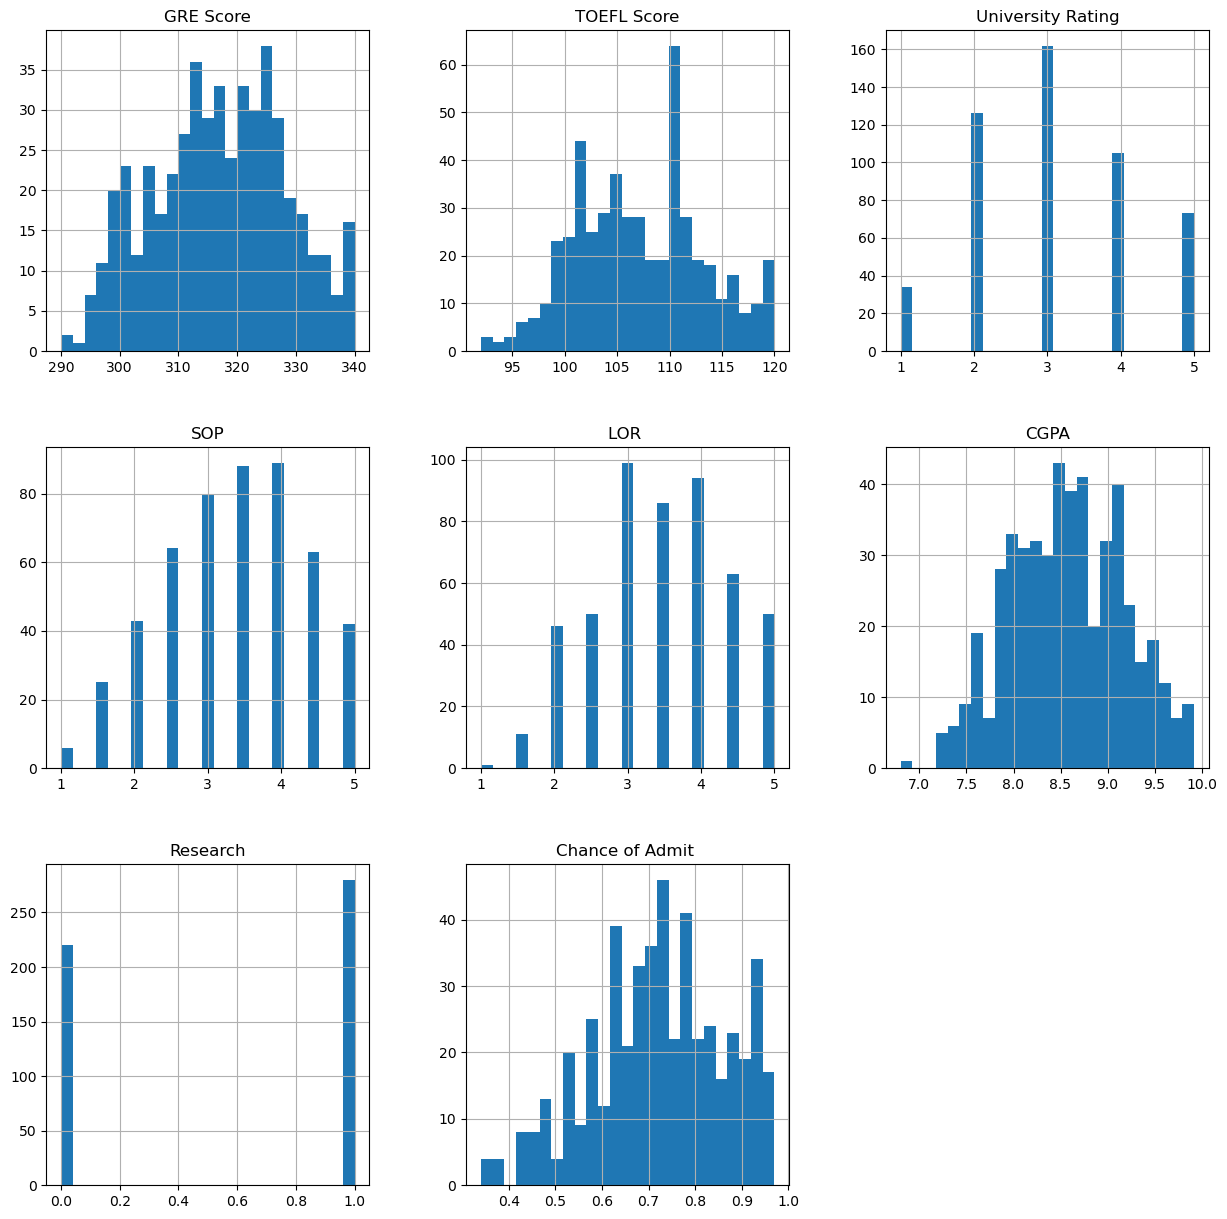

In [4]:
# Hitogramas de las varaibles del dataset
data.hist(bins=25, figsize=(15,15))
plt.show()

In [5]:
# Definición de variables predictoras (X)
X = data.drop(data.columns[-1], axis=1)
# Definición de variable de interés (y)
Y = data[data.columns[-1]]

In [6]:
# Separación de variables predictoras (X) y variable de interés (y) en set de entrenamiento y test usandola función train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(X,Y,test_size=0.3, random_state=22)

## Punto 1 - Red Neuronal de una capa

En la celda 1 creen una **red neuronal de una capa** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes, usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador y el número de épocas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [7]:
yTrain

Serial No.
429    0.69
42     0.49
219    0.84
148    0.83
13     0.78
       ... 
357    0.79
449    0.80
301    0.62
133    0.71
374    0.79
Name: Chance of Admit , Length: 350, dtype: float64

##### Selección de parámetros:

* Función de pérdida: Para definir nuestra función de pérdida usaremos el Error cuadrático medio, usaremos este indicador porque por su naturaleza cuadrática penaliza mucho más fuerte errores más grandes de la muestra, a diferencia de otros indicadores en los que la relación es más lineal.
* Número de épocas: Teniendo en cuenta que estamos trabajando con un Dataset pequeño, 350 observaciones sería recomendable tener un número de épocas entre las 50 y las 200, por lo cual trabajaremos con 100 épocas que parece un buen parámetro para balancear el fit, si observamos overfitting en nuestras gráficas trabajaremos con un número menor de épocas.
* Optimizador: Usaremos Stockastic Gradient Descent debido a que fue el que vimos en clase; sin embargo, de acuerdo a nuestra investigación entre los optimizadores está la posibilidad de usar:
  * Adaptive Moment Estimation ADAM: El estandar de la industria hoy en día ya que permite rápida convergencia a la solución al incluir métricas de "momentum" en los gradientes.
  * RMSprop: Precursor del optimizador ADAM al usar diferentes tasas de aprendizaje para diferentes parámetros a diferencia del STD.
  


In [13]:
# Celda 1

# Normalización de variables predictoras (X) con la función StandardScaler
from sklearn.preprocessing import StandardScaler

# Definición de la función StandardScaler
scaler = StandardScaler()
scaler.fit(X)

# Transformación de los set de entrenamiento y test
X_train = pd.DataFrame(data=scaler.transform(xTrain), columns=xTrain.columns, index=xTrain.index)
X_test = pd.DataFrame(data=scaler.transform(xTest), columns=xTest.columns, index=xTest.index)

X_train = np.array(X_train)
Y_train = np.array(yTrain)

X_test = np.array(X_test)
Y_test = np.array(yTest)


In [18]:
K.clear_session()

# Celda 1
#Primero definimos el modelo
model = Sequential()
model.add(Dense(1, input_shape=(7,)))

# Compilamos el modelo
model.compile(optimizer = 'adam', loss='mean_squared_error', metrics=['mae', 'mse'])

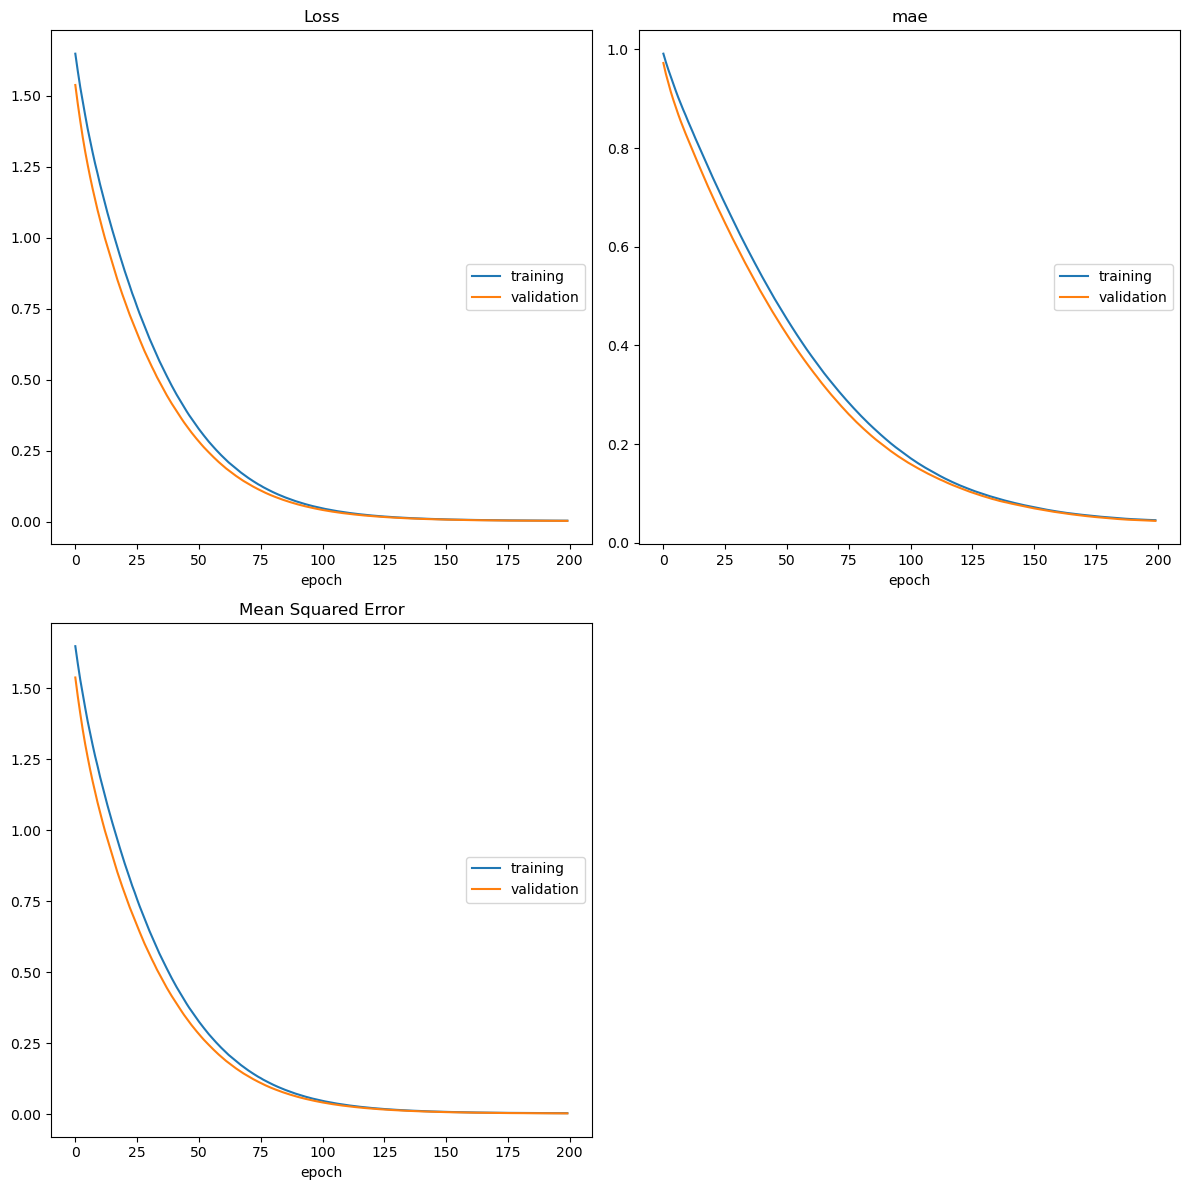

Loss
	training         	 (min:    0.004, max:    1.647, cur:    0.004)
	validation       	 (min:    0.004, max:    1.537, cur:    0.004)
mae
	training         	 (min:    0.046, max:    0.991, cur:    0.046)
	validation       	 (min:    0.044, max:    0.972, cur:    0.044)
Mean Squared Error
	training         	 (min:    0.004, max:    1.647, cur:    0.004)
	validation       	 (min:    0.004, max:    1.537, cur:    0.004)
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0042 - mae: 0.0458 - mse: 0.0042 - val_loss: 0.0035 - val_mae: 0.0444 - val_mse: 0.0035


In [19]:
# Entrenamiento de la red neuronal con 100 épocas
model.fit(X_train, Y_train,
          verbose=1,
          epochs=100,
          validation_data=(X_test, Y_test),
          callbacks=[PlotLossesKeras()])

In [20]:
loss, mae, mse = model.evaluate(X_test, Y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0035 - mae: 0.0444 - mse: 0.0035


In [17]:
# epoca con menor error de validación
history = model.history.history
min_val_loss_epoch = np.argmin(history['val_loss'])
print(f"Época con menor error de validación: {min_val_loss_epoch + 1}")

Época con menor error de validación: 100


## Punto 2 - Red Neuronal multicapa

En la celda 2 creen una **red neuronal con dos capas** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

##### Selección de parámetros:

* Función de pérdida: Mantenemos MSE como la función de pérdida de nuestro modelo buscando que los resultados del modelo con una o varias capas sean comparables.
* Número de épocas: Mantendremos nuestro número de épocas en 100 que nos dio buenos resultados en el ejercicio anterior.
* Optimizador: Esta vez usaremos el optimizador tipo Adam buscando aproximarnos más a los estándares de la industria y entender mejor si hay una mejora significativa en los tiempos de convergencia de nuestro modelo.
* Número de capas: Como sabemos no hay una teoría que nos formule directamente el número de capas que deben ser usadas en un modelo de redes neuronales, sabemos que a más capas tendremos mejores resultados y que el número de neuronas por capa debe ser: un número entre 1 y 7 (número de variables explicativas) y adicionalmente debe ser descendente, es decir a medida que pasamos de una capa a la siguiente debemos ir reduciendo el número de neuronas por capa, por lo tanto trabajaremos con un modelo de 3 capas ocultas y el número de neuronas por capa será de 7, 5, 3, para la primera, segunda y tercera capa oculta respectivamente. 

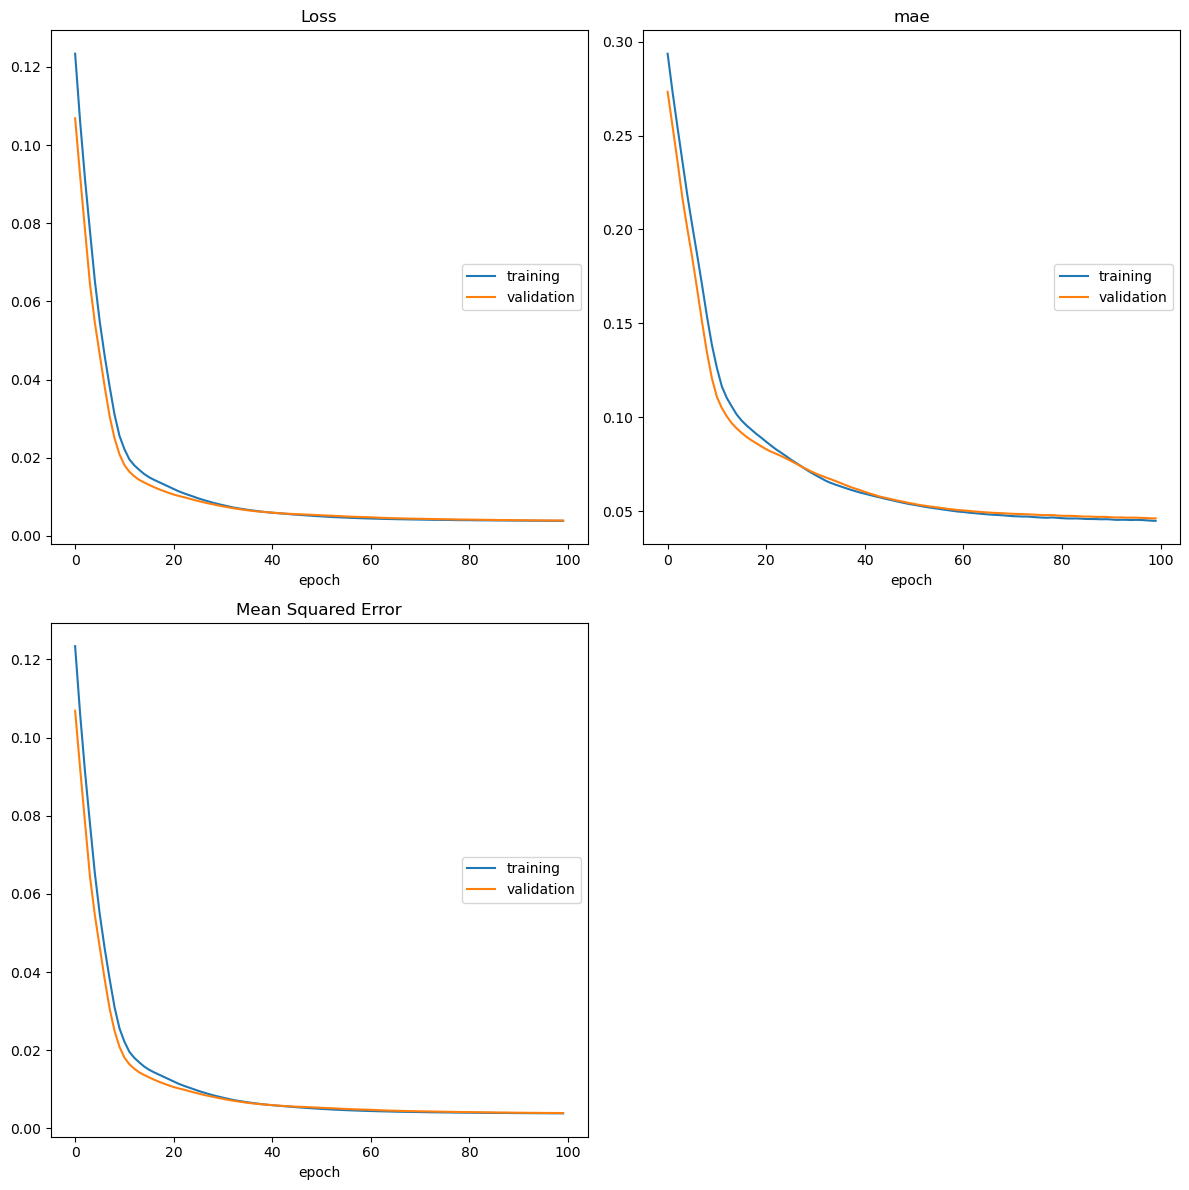

Loss
	training         	 (min:    0.004, max:    0.123, cur:    0.004)
	validation       	 (min:    0.004, max:    0.107, cur:    0.004)
mae
	training         	 (min:    0.045, max:    0.294, cur:    0.045)
	validation       	 (min:    0.046, max:    0.273, cur:    0.046)
Mean Squared Error
	training         	 (min:    0.004, max:    0.123, cur:    0.004)
	validation       	 (min:    0.004, max:    0.107, cur:    0.004)
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0038 - mae: 0.0448 - mse: 0.0038 - val_loss: 0.0039 - val_mae: 0.0461 - val_mse: 0.0039


In [22]:
# Celda 2

K.clear_session()

model2 = Sequential()
model2.add(Dense(7, input_shape=(7,)))
model2.add(Dense(5, activation='relu'))
model2.add(Dense(3, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae', 'mse'])

model2.fit(X_train, Y_train,
           verbose=1,
           epochs=100,
           validation_data=(X_test, Y_test),
           callbacks=[PlotLossesKeras()])

In [23]:
loss2, mae2, mse2 = model2.evaluate(X_test, Y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0039 - mae: 0.0461 - mse: 0.0039


In [24]:
# epoca con menor error de validación
history2 = model2.history.history
min_val_loss_epoch2 = np.argmin(history2['val_loss'])
print(f"Época con menor error de validación en modelo de 2 capas: {min_val_loss_epoch2 + 1}")

Época con menor error de validación en modelo de 2 capas: 100


## Punto 3  - Red Neuronal multicapa

En la celda 3 creen **una red neuronal con más de una capa con la librería Keras, usando early stopping y dropout,** que prediga la probabilidad de admisión de los estudiantes con los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

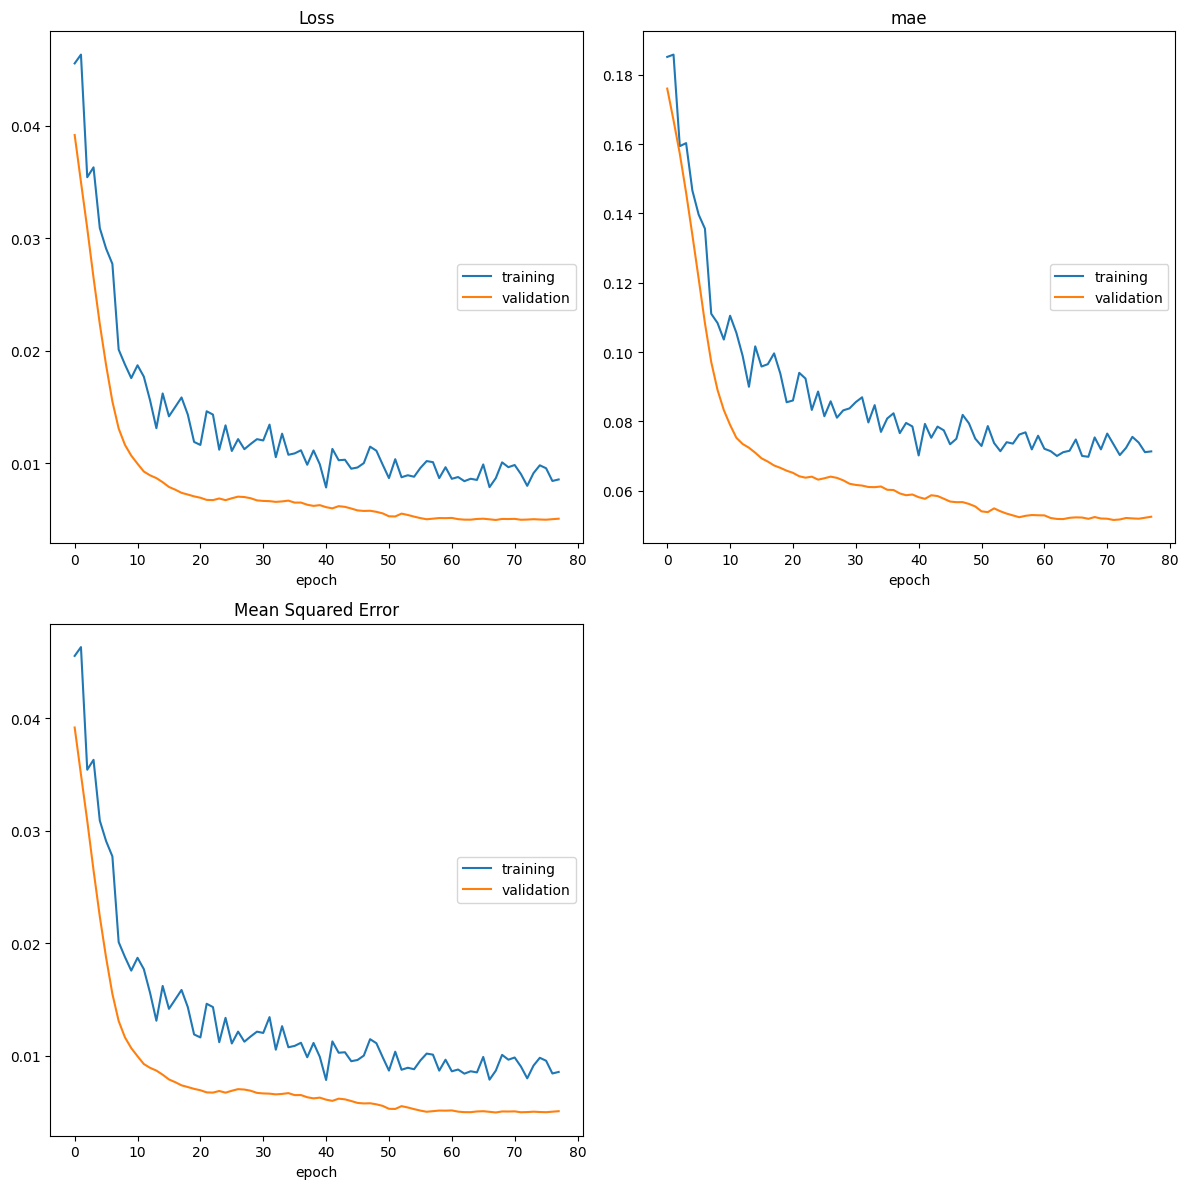

Loss
	training         	 (min:    0.008, max:    0.046, cur:    0.009)
	validation       	 (min:    0.005, max:    0.039, cur:    0.005)
mae
	training         	 (min:    0.070, max:    0.186, cur:    0.071)
	validation       	 (min:    0.052, max:    0.176, cur:    0.053)
Mean Squared Error
	training         	 (min:    0.008, max:    0.046, cur:    0.009)
	validation       	 (min:    0.005, max:    0.039, cur:    0.005)
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0085 - mae: 0.0714 - mse: 0.0085 - val_loss: 0.0051 - val_mae: 0.0525 - val_mse: 0.0051


In [16]:
# Celda 3

K.clear_session()

model3 = Sequential()
model3.add(Dense(7, input_shape=(7,)))
model3.add(Dense(5, activation='relu'))
model3.add(Dropout(0.2))
model3.add(Dense(3, activation='relu'))
model3.add(Dropout(0.2))
model3.add(Dense(1, activation='sigmoid'))

model3.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae', 'mse'])
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

model3.fit(X_train, Y_train,
           verbose=1,
           epochs=100,
           validation_data=(X_test, Y_test),
           callbacks=[PlotLossesKeras(), early_stopping])


In [17]:
loss3, mae3, mse3 = model3.evaluate(X_test, Y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0051 - mae: 0.0525 - mse: 0.0051 


In [18]:
# epoca con menor error de validación
history3 = model3.history.history
min_val_loss_epoch3 = np.argmin(history3['val_loss'])

print(f"Época con menor error de validación en modelo de 3 capas: {min_val_loss_epoch3 + 1}")

Época con menor error de validación en modelo de 3 capas: 68


## Punto 4 - Comparación y análisis de resultados

En la celda 4 comparen los resultados obtenidos de las diferentes redes y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

In [20]:
resultados = pd.DataFrame({
    'Modelo': [
        'Red neuronal una capa',
        'Red neuronal multicapa',
        'Red multicapa con regularización'
    ],
    'Loss': [
        loss,
        loss2,
        loss3
    ],
    'MAE': [
        mae,
        mae2,
        mae3
    ],
    'MSE': [
        mse,
        mse2,
        mse3
    ]
})

resultados

,Modelo,Loss,MAE,MSE
0,Red neuronal una capa,0.003175,0.040906,0.003175
1,Red neuronal multicapa,0.004140,0.048307,0.004140
2,Red multicapa con regularización,0.005055,0.052535,0.005055


**Análisis de resultados**

Los resultados muestran que el modelo de red neuronal de una sola capa obtuvo el mejor desempeño, alcanzando el menor valor de pérdida (Loss = 0.0032) y el menor error absoluto medio (MAE = 0.0416). Esto indica que el modelo logró ajustarse adecuadamente a los datos y generalizar correctamente sobre el conjunto de prueba.

Por otro lado, la red neuronal multicapa presentó un desempeño ligeramente inferior. Aunque logró aprender patrones más complejos, se observó una leve diferencia entre las curvas de entrenamiento y validación, lo que sugiere un inicio de overfitting después de varias épocas de entrenamiento.

Finalmente, el modelo multicapa con técnicas de regularización como Dropout mostró un comportamiento más estable durante el entrenamiento. Sin embargo, su desempeño final fue inferior respecto al modelo más simple. Esto puede explicarse porque el conjunto de datos utilizado no es lo suficientemente complejo como para requerir arquitecturas profundas o altos niveles de regularización.

Al aumentar el número de épocas a 100, se obtuvo mayor precisión en los resultados de cada modelo si se compara con dejarlo en 50 épocas. Adicionalmente, en el punto 3, se observa que el modelo multicapa con early stoppping se detiene antes de la época 80. Esto puede implicar que el modelo encontró un óptimo local y se mantvo allí, lo que puede ser inadecuado al buscar la mejor solución posible y además el desmpeño es inferior a los 2 primeros modelos.

En las métricas de desempeño del modelo 3, se observa que el conjunto de entrenamiento tiene un comportamiento con saltos erráticos frente a los modelos 1 y 2. Esto puede ser por la inclusión del dropout, el cual desactiva aleatoriamente un 20% de 'neuronas' en cada interación de su entrenamiento para evitar el overfitting.

En conclusión, para este problema de predicción de probabilidad de admisión universitaria, una arquitectura sencilla fue suficiente para obtener los mejores resultados. Esto demuestra que modelos más complejos no siempre generan un mejor desempeño y que la selección de arquitectura debe depender de la naturaleza y complejidad de los datos.